# Projeto Integrado - Quantum Finance

Este notebook apresenta meu fluxo de trabalho para prever o Credit Scoring dos clientes usando um modelo de regressão linear múltipla.

**Etapas realizadas:**
1. Configuração e inicialização do PySpark.
2. Leitura e pré-processamento dos dados.
3. Tratamento das variáveis categóricas (com conversão para variáveis dummy via Pipeline).
5. Análise descritiva e de correlação para entender os dados.
6. Ajuste do modelo de regressão linear múltipla e avaliação do desempenho.
7. Interpretação dos coeficientes por meio de gráficos.

####Environment variables:

In [ ]:
import os

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.3.2-bin-hadoop3"

####PySpark start

In [ ]:
import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("projeto_integrado_QF") \
    .getOrCreate()

####Mount Drive

In [ ]:
from google.colab import drive

# Montar o Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


####Import Libs

In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.stat import Correlation
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.functions import vector_to_array
from pyspark.ml import Pipeline
from pyspark.sql.types import NumericType
from pyspark.sql.functions import *
import seaborn as sns
import matplotlib.pyplot as plt
import json

###Data Source

In [ ]:
#Alterar o caminho do arquivo caso necessário
file_path = '/content/drive/MyDrive/MBA - FIAP/Discovery Google/Applied statistics/alldata_quantum.csv'

# Ler o arquivo sem usar o cabeçalho
df_raw = spark.read.csv(file_path, header=True, sep=";", encoding="latin1", inferSchema=True)

df_raw = (
    df_raw
    .withColumnRenamed("ID", "id")
    .withColumnRenamed('Qte_dependentes', 'qtd_dependentes')
    .withColumnRenamed('tempo_ultimoservico', 'tempo_servico')
    .withColumnRenamed('vl_salario_mil', 'vl_salario')
    .withColumnRenamed('vl_imovel_em_mil', 'vl_imovel')
    .withColumnRenamed('Qte_cartoes', 'qtd_cartoes')
    .withColumnRenamed('Qte_carros', 'qtd_carros')
    .withColumnRenamed('SCORE_CREDITO', 'score')

)

df_raw = (
  df_raw
  .replace("null", None) ## Ajuste de valores Nullos pois o DF estava interpretando como texto
  .withColumn('score', regexp_replace(col("score"), ",", ".").cast('float')) ##Cast do score para float, pois o DF está interpretando como String
  .withColumn('vl_salario', regexp_replace(col("vl_salario"), ",", ".").cast('float')) ##Cast do vl_salario para float, pois o DF está interpretando como String
)

df_raw.show(10)

df_raw.printSchema()

+---------+-----+----+------------+-------------+---------------+-------------+--------+----------+-----------+------------+---------+-----------+----------+-----+
|       id|idade|sexo|estado_civil|       escola|qtd_dependentes|tempo_servico|trabalha|vl_salario|reg_moradia|casa_propria|vl_imovel|qtd_cartoes|qtd_carros|score|
+---------+-----+----+------------+-------------+---------------+-------------+--------+----------+-----------+------------+---------+-----------+----------+-----+
|708082083|   45|   F|      casado|    graduacao|              3|           40|       1| 40.089664|          3|           0|        0|          1|         1|778.0|
|708083283|   58|   M|    solteiro|ensino fundam|              0|           44|       1|  66.55765|          3|           0|        0|          1|         0|276.3|
|708084558|   46|   M|  divorciado|    doutorado|              3|           35|       1| 123.68182|          6|           0|        0|          1|         1|401.0|
|708085458|   34

####Schema details



*   id - Id do usuário
*   idade - Idado em anos, do usuário
*   sexo - Sexo do usuário (M/F)
*   estado_civil - Estado civil do usuário (Solteiro, Casado, Divorciado)
*   escola - Grau de escolaridade do usuário (ensino fundam, ensino medio, graduacao, doutorado)
*   qtd_dependentes - Quantidade de dependentes do usuário
*   tempo_servico - Tempo de trabalho (meses)
*   trabalha - Booleano de estado de trabalho (1/0)
*   vl_salario - Valor do salario em K (float)
*   reg_moradia - Região onde o usuário mora (1-A .. 6-F)
*   casa_propria - Booleano de casa própria (1/0)
*   vl_imovel - Valor dp imóvel em K (int)
*   qtd_cartoes - Quantidade de cartões do usuário (int)
*   qtd_carros - Quantidade de carros do usuário (int)
*   score - Credit Scoring



In [ ]:
ProfAdelaide OK!

###Global Variable

In [ ]:
categorical_columns = ["sexo", "estado_civil", "escola", "reg_moradia"]

###Feature Engineer

####Ajuste de variáveis categóricas

In [ ]:
# Exemplo de pipeline com indexadores e encoders (você já tem algo similar)
indexer_sexo = StringIndexer(inputCol="sexo", outputCol="sexo_index", handleInvalid="keep")
indexer_estado = StringIndexer(inputCol="estado_civil", outputCol="estado_civil_index", handleInvalid="keep")
indexer_escola = StringIndexer(inputCol="escola", outputCol="escola_index", handleInvalid="keep")
indexer_reg = StringIndexer(inputCol="reg_moradia", outputCol="reg_moradia_index", handleInvalid="keep")

encoder_sexo = OneHotEncoder(inputCol="sexo_index", outputCol="sexo_vec")
encoder_estado = OneHotEncoder(inputCol="estado_civil_index", outputCol="estado_civil_vec")
encoder_escola = OneHotEncoder(inputCol="escola_index", outputCol="escola_vec")
encoder_reg = OneHotEncoder(inputCol="reg_moradia_index", outputCol="reg_moradia_vec")

# Variáveis numéricas
numeric_features = ["idade", "qtd_dependentes", "tempo_servico", "trabalha",
                    "vl_salario", "casa_propria", "vl_imovel", "qtd_cartoes", "qtd_carros"]

# Vetores categóricos (resultados do OneHotEncoder)
encoded_features = ["sexo_vec", "estado_civil_vec", "escola_vec", "reg_moradia_vec"]

assembler = VectorAssembler(
    inputCols=numeric_features + encoded_features,
    outputCol="features"
)

pipeline = Pipeline(stages=[
    indexer_sexo, indexer_estado, indexer_escola, indexer_reg,
    encoder_sexo, encoder_estado, encoder_escola, encoder_reg,
    assembler
])

# Ajusta o pipeline e transforma o DataFrame original
df_model = pipeline.fit(df_raw).transform(df_raw)

# ---------------------------------------------
# 1) Função para extrair nomes de cada atributo do schema
# ---------------------------------------------
def get_feature_names(df, vec_col="features"):
    """
    Lê o metadata do schema para obter os nomes das features
    (incluindo as categorias geradas pelo OneHotEncoder).
    """
    # Atributos ficam armazenados em df.schema[vec_col].metadata["ml_attr"]["attrs"]
    metadata = df.schema[vec_col].metadata["ml_attr"]["attrs"]
    # Pode haver chaves como "numeric", "binary" ou "nominal"
    all_attrs = []
    for attr_type in metadata:
        all_attrs.extend(metadata[attr_type])
    # Cada attr é um dict com 'idx' e 'name'
    # Precisamos ordenar para garantir a correspondência correta
    all_attrs = sorted(all_attrs, key=lambda x: x["idx"])
    return [attr["name"] for attr in all_attrs]

feature_names = get_feature_names(df_model, "features")

df_array = df_model.withColumn("features_array", vector_to_array("features"))

for i, fname in enumerate(feature_names):
    df_array = df_array.withColumn(fname, col("features_array")[i])

# Agora você tem colunas individuais para cada variável
df_array.select(["score"] + feature_names).show(10, truncate=False)

+-----+-----+---------------+-------------+--------+------------------+------------+---------+-----------+----------+----------+----------+-----------------------+-------------------------+-------------------+---------------------------+-----------------------+------------------------+--------------------+-------------------+--------------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+
|score|idade|qtd_dependentes|tempo_servico|trabalha|vl_salario        |casa_propria|vl_imovel|qtd_cartoes|qtd_carros|sexo_vec_F|sexo_vec_M|estado_civil_vec_casado|estado_civil_vec_solteiro|estado_civil_vec_na|estado_civil_vec_divorciado|escola_vec_ensino medio|escola_vec_ensino fundam|escola_vec_graduacao|escola_vec_mestrado|escola_vec_doutorado|reg_moradia_vec_3|reg_moradia_vec_4|reg_moradia_vec_5|reg_moradia_vec_6|reg_moradia_vec_2|reg_moradia_vec_1|
+-----+-----+---------------+-------------+--------+------------------+------------+--

In [ ]:
df_raw = df_array.drop(
    "features",
    "features_array",
    "sexo_vec",
    "estado_civil_vec",
    "escola_vec",
    "reg_moradia_vec",
    'sexo_index',
    'estado_civil_index',
    'escola_index',
    'reg_moradia_index',
    "id" ##Removendo ID pois trata-se de um indicador numérico classificatório sem relação com os demais, podendo ser ofensor do modelo
)
df_raw.show(10)
df_raw.printSchema()

+-----+----+------------+-------------+---------------+-------------+--------+------------------+-----------+------------+---------+-----------+----------+-----+----------+----------+-----------------------+-------------------------+-------------------+---------------------------+-----------------------+------------------------+--------------------+-------------------+--------------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+
|idade|sexo|estado_civil|       escola|qtd_dependentes|tempo_servico|trabalha|        vl_salario|reg_moradia|casa_propria|vl_imovel|qtd_cartoes|qtd_carros|score|sexo_vec_F|sexo_vec_M|estado_civil_vec_casado|estado_civil_vec_solteiro|estado_civil_vec_na|estado_civil_vec_divorciado|escola_vec_ensino medio|escola_vec_ensino fundam|escola_vec_graduacao|escola_vec_mestrado|escola_vec_doutorado|reg_moradia_vec_3|reg_moradia_vec_4|reg_moradia_vec_5|reg_moradia_vec_6|reg_moradia_vec_2|reg_moradia_vec_1

#### Análise descritiva das variáveis

In [ ]:
# 1. Estatísticas descritivas para colunas numéricas
print("Estatísticas descritivas para colunas numéricas:")
df_raw.describe().show()

print('')
print("-----------------------------------------------------------------")
print('')

print("Contagem de valores faltantes por coluna:")
missing_counts = df_raw.select([sum(col(c).isNull().cast("int")).alias(c) for c in df_raw.columns])
missing_counts.show()

print('')
print("-----------------------------------------------------------------")
print('')

for column in categorical_columns:
    print(f"Distribuição de frequência para a coluna '{column}':")
    df_raw.groupBy(column).count().orderBy("count", ascending=False).show()

Estatísticas descritivas para colunas numéricas:
+-------+-----------------+-----+------------+---------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+------------------+-----------------+-------------------+-------------------+-----------------------+-------------------------+-------------------+---------------------------+-----------------------+------------------------+--------------------+-------------------+--------------------+-------------------+-------------------+-------------------+------------------+-------------------+-------------------+
|summary|            idade| sexo|estado_civil|   escola|   qtd_dependentes|     tempo_servico|          trabalha|        vl_salario|       reg_moradia|       casa_propria|         vl_imovel|        qtd_cartoes|        qtd_carros|            score|         sexo_vec_F|         sexo_vec_M|estado_civil_vec_casado|estado_civil_vec_solteir

ProfAdelaide As analises descritivas acima não fora, adequadas para analisar. Por ser uma técnica supervisionada
             é relevante a analise de uma varia´vel preditora com a variável target, aqui por set a variavel target quantitativa
             pode se fazer uma tabela com a médi ado score por categoria da variavel ou um box plot das categorias com a target.
             

#### Outlier Analysis

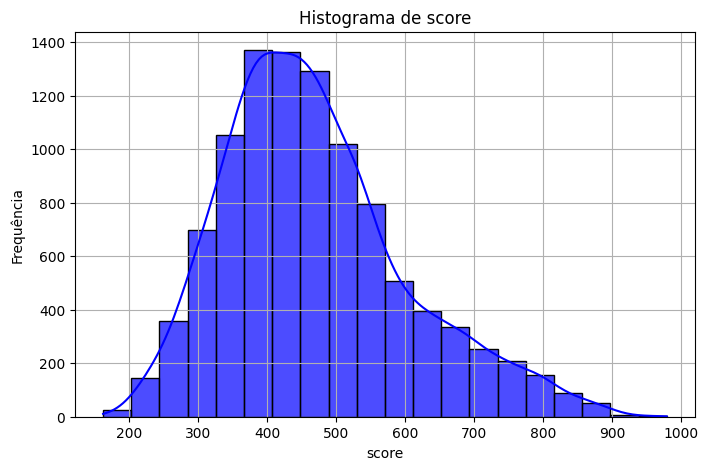

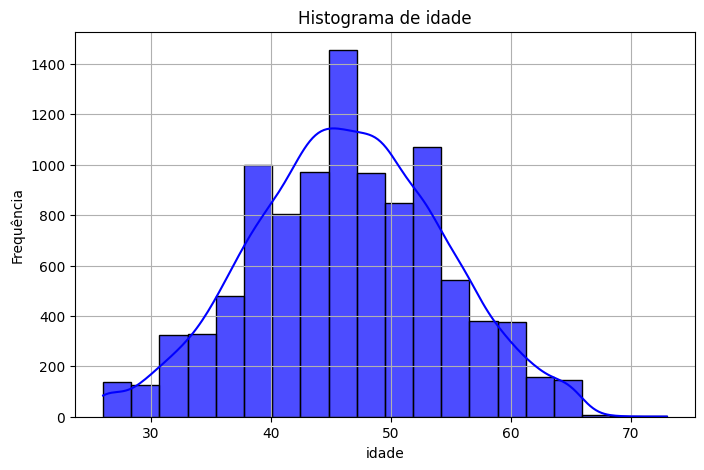

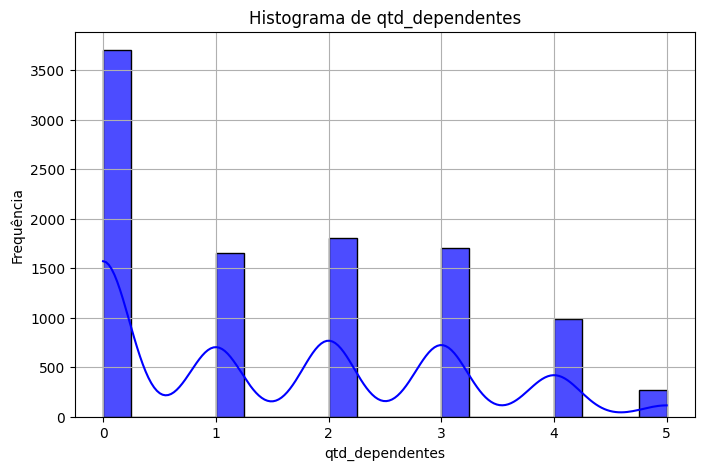

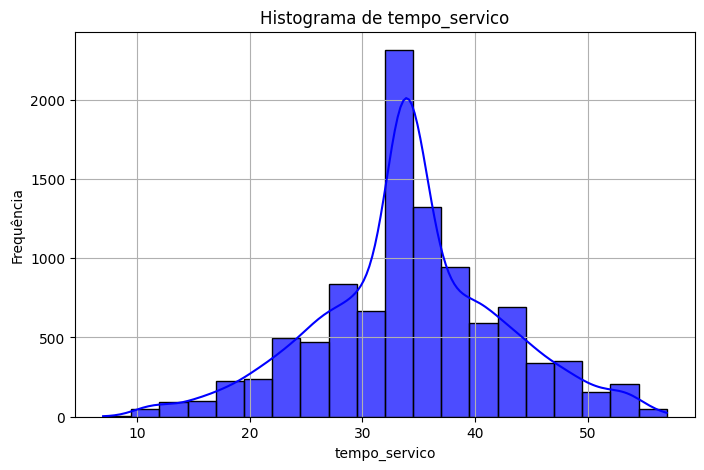

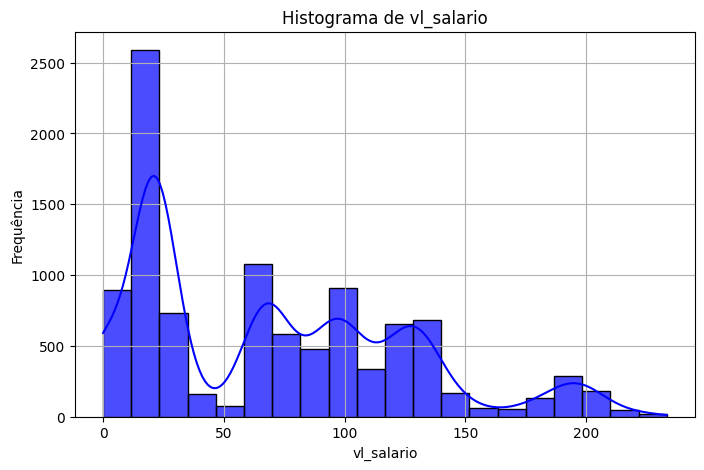

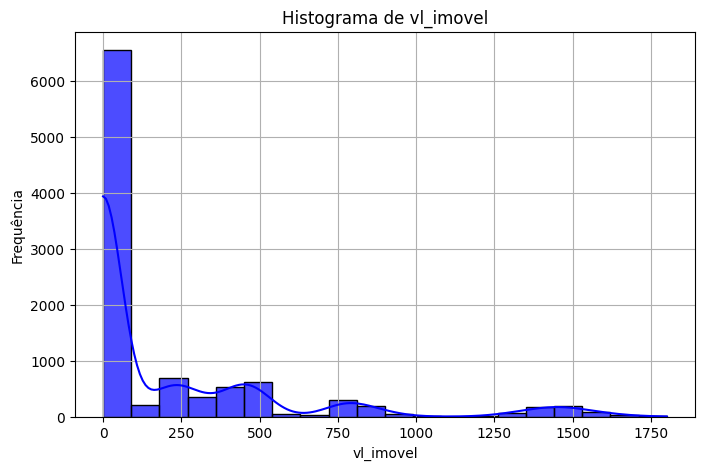

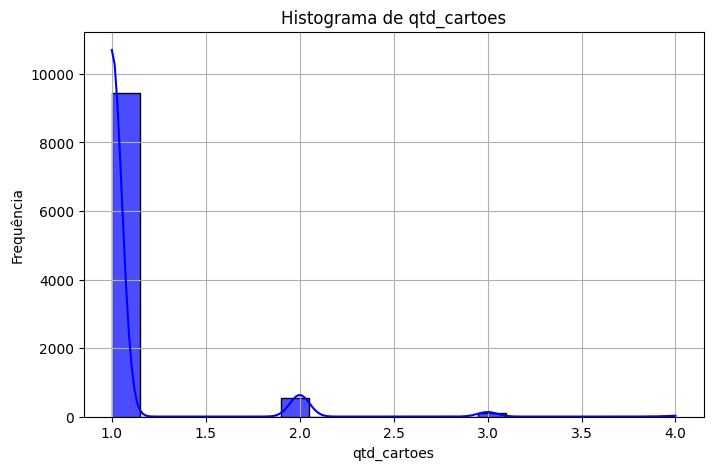

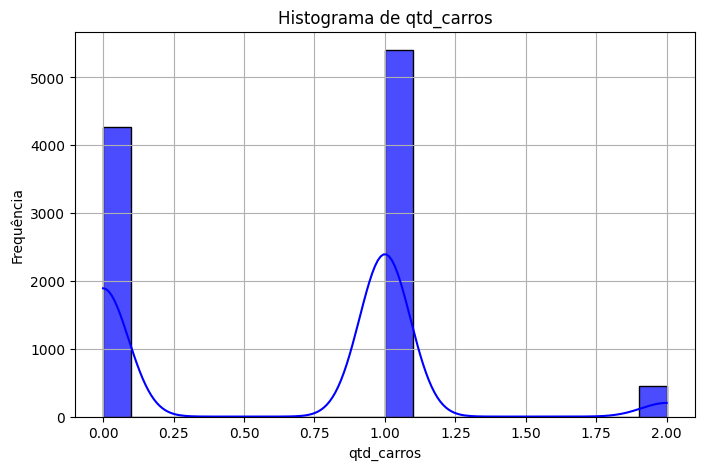

In [ ]:
# Lista de colunas numéricas (excluindo as binárias categóricas)
colunas_numericas = [
    "score", "idade", "qtd_dependentes", "tempo_servico", "vl_salario", "vl_imovel",
    "qtd_cartoes", "qtd_carros"
]

# Criando os histogramas
for coluna in colunas_numericas:
    # Coletando os valores da coluna como lista de números
    valores = [row[coluna] for row in df_raw.select(coluna).collect()]

    # Criando o histograma
    plt.figure(figsize=(8, 5))
    sns.histplot(valores, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.7)

    # Configuração do gráfico
    plt.title(f"Histograma de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.grid(True)

    # Exibir o gráfico
    plt.show()


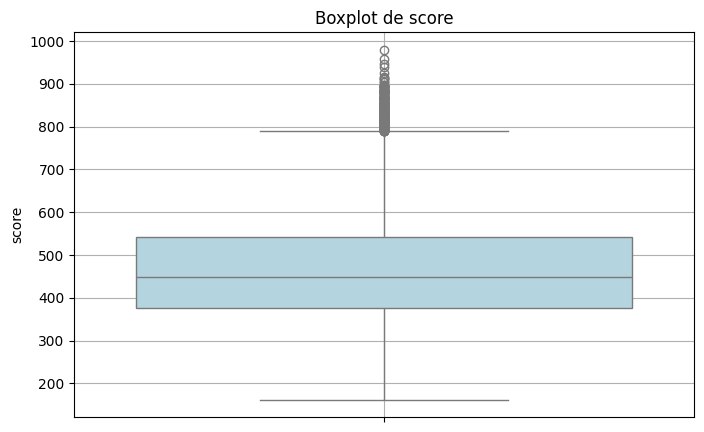

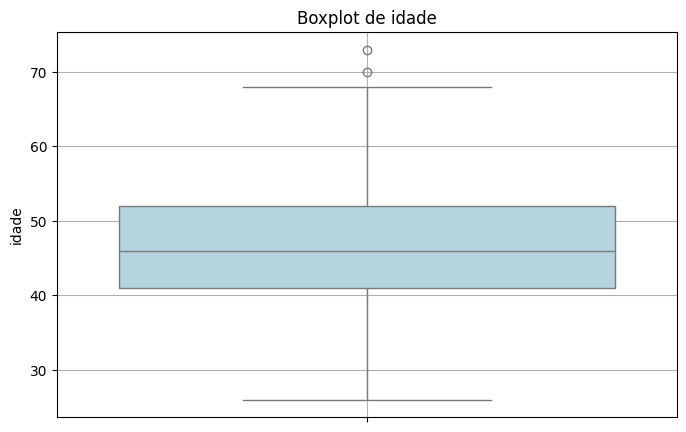

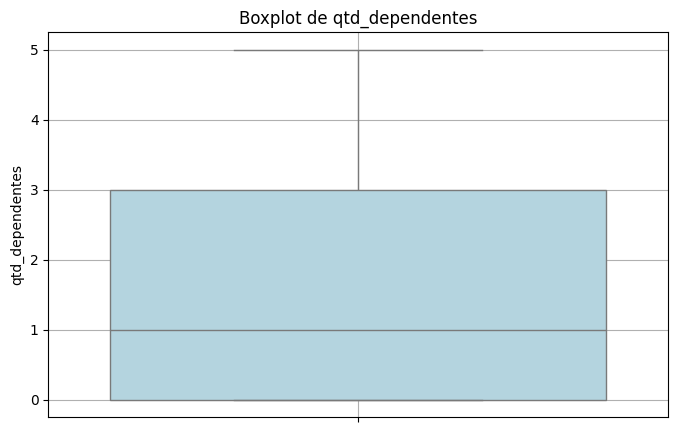

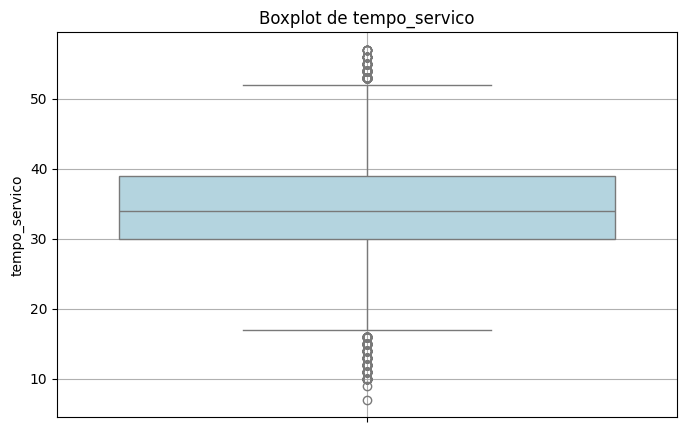

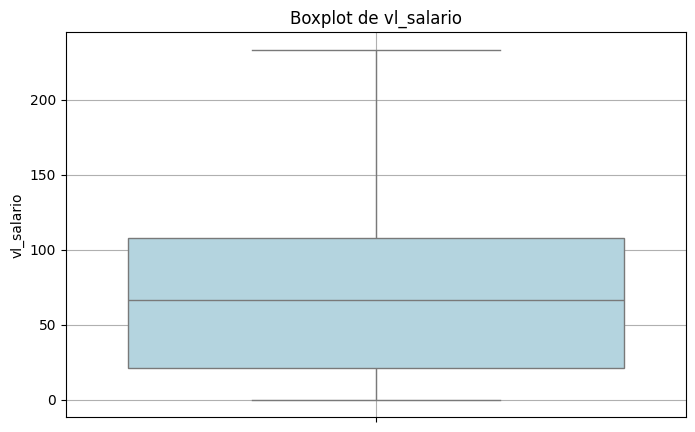

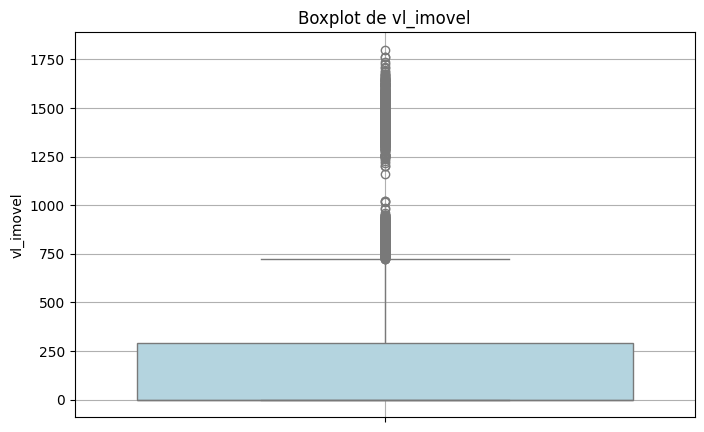

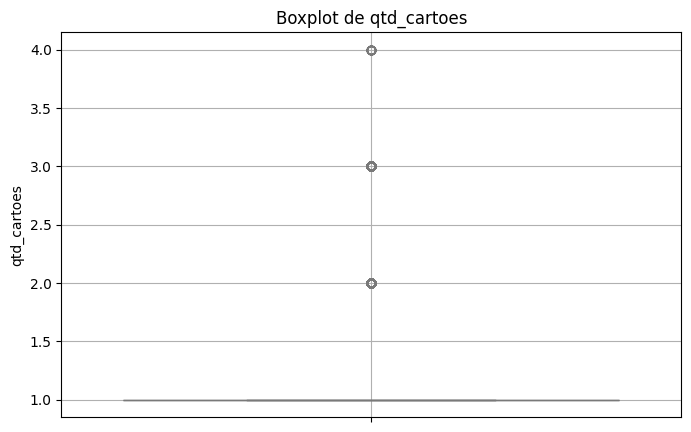

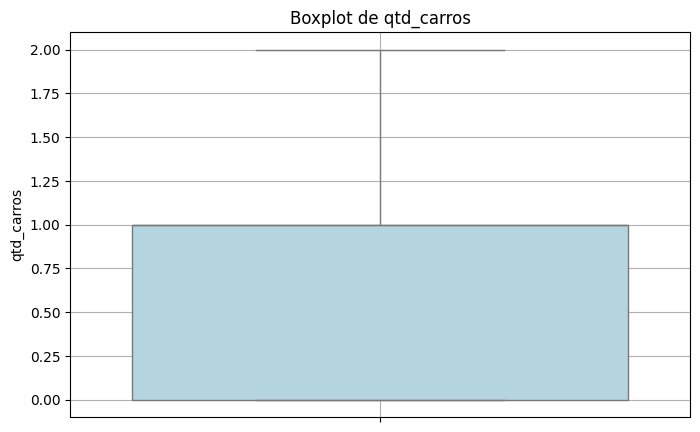

In [ ]:
# Lista de colunas numéricas (excluindo variáveis binárias categóricas)
colunas_numericas = [
    "score", "idade", "qtd_dependentes", "tempo_servico", "vl_salario", "vl_imovel",
    "qtd_cartoes", "qtd_carros"
]

# Criando boxplots para cada coluna
for coluna in colunas_numericas:
    # Convertendo a coluna para numérica (caso necessário)
    df_raw = df_raw.withColumn(coluna, col(coluna).cast("double"))

    # Coletando os valores da coluna como lista
    valores = [row[coluna] for row in df_raw.select(coluna).collect()]

    # Criando o boxplot
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=valores, color="lightblue")

    # Configuração do gráfico
    plt.title(f"Boxplot de {coluna}")
    plt.ylabel(coluna)
    plt.grid(True)

    # Exibir o gráfico
    plt.show()

##### Conclusões
- Após a geração dos histogramas e boxplots para as variáveis numéricas do dataset, podemos fazer algumas observações importantes sobre a distribuição dos dados e a presença de outliers.
<br>
<br>
**Distribuição das Variáveis**
<br>
- A análise dos histogramas mostrou que as variáveis seguem, em geral, distribuições normais ou lineares, sem grandes assimetrias ou concentrações incomuns.
<br>
- Para algumas variáveis como Valor do imovel e quantidade de cartões tem grande concentração em um valor, aqui pode ser que seja interessante dividir em dois grupos, esse valor e os outros, caso a análise posterior do modelo identifique necessidade. Ou até desconsiderar a variável a depender do impacto na correlação.
<br>
- Dos restantes das colunas, os dados estão relativamente bem distribuídos, sem padrões que exijam transformações ou ajustes significativos.
<br>
<br>
**Identificação de Outliers**
<br>
- A partir dos boxplots, identificamos alguns outliers em certas variáveis. No entanto, é importante destacar que identificamos os outliers em: score, tempo_servico, vl_imovel, como grupos das respectivas variáveis, alguns desses valores podem corresponder a grupos específicos de clientes e, ao removê-los, poderíamos perder informações valiosas sobre determinados perfis.
<br>
- Das restantes colunas, a maioria desses outliers ocorre em frequências muito baixas, ou seja, representam poucos casos isolados.
<br>
<br>
**Considerações finais - OUTLIERS**
<br>
- A distribuição dos dados não apresentou padrões anômalos que exijam preocupações imediatas.
<br>
- Embora existam outliers, eles estão em baixa frequência e, em alguns casos, representam segmentos específicos.
<br>
- Como os valores extremos não estão distorcendo as distribuições gerais, não há necessidade de removê-los agora, se necessário voltamos aos outliers.

In [ ]:
ProfAdelaide As avaliações e considerações colocadas sobre as variáveis preditoras ficaram OK!
             Senti falta aqui se gráficos de scattee e boxplot dessas variáveis preditoras e a variavel target score
             Com esses gráficos já poderia ter alguns "insights" da importância das variáveis para estimar o score

####Removendo as variáveis categóricas

In [ ]:
df_raw = df_raw.drop("sexo", "estado_civil", "escola", "reg_moradia")
df_raw.printSchema()

root
 |-- idade: double (nullable = true)
 |-- qtd_dependentes: double (nullable = true)
 |-- tempo_servico: double (nullable = true)
 |-- trabalha: double (nullable = true)
 |-- vl_salario: double (nullable = true)
 |-- casa_propria: double (nullable = true)
 |-- vl_imovel: double (nullable = true)
 |-- qtd_cartoes: double (nullable = true)
 |-- qtd_carros: double (nullable = true)
 |-- score: float (nullable = true)
 |-- sexo_vec_F: double (nullable = true)
 |-- sexo_vec_M: double (nullable = true)
 |-- estado_civil_vec_casado: double (nullable = true)
 |-- estado_civil_vec_solteiro: double (nullable = true)
 |-- estado_civil_vec_na: double (nullable = true)
 |-- estado_civil_vec_divorciado: double (nullable = true)
 |-- escola_vec_ensino medio: double (nullable = true)
 |-- escola_vec_ensino fundam: double (nullable = true)
 |-- escola_vec_graduacao: double (nullable = true)
 |-- escola_vec_mestrado: double (nullable = true)
 |-- escola_vec_doutorado: double (nullable = true)
 |-- r

In [ ]:
ProfAdelaide OK!as transformações ficaram ok! 
                Aqui tambem sent falta de algunms graficos com as variáveis categóricas, por exemplo,
                Boxplot das categorias de cada variavel com a variavel target

                No caso de dado faltante vocês deixaram em uma categoria, ok! mas poderiam ter estimado ou 
                não criar dummmy para essa categoria(na)

#### Análise de correlação das variáveis

In [ ]:
# Seleciona automaticamente todas as colunas numéricas do DataFrame
numeric_cols = [field.name for field in df_raw.schema.fields if isinstance(field.dataType, NumericType)]
print("Colunas numéricas detectadas:", numeric_cols)

# Monta o vetor de features com todas as colunas numéricas
assembler = VectorAssembler(inputCols=numeric_cols, outputCol="features")
df_vector = assembler.transform(df_raw)

# Calcula a matriz de correlação para o vetor de features
corr_result = Correlation.corr(df_vector, "features").head()[0]
corr_matrix = corr_result.toArray()

# Converte a matriz em um DataFrame do Pandas para exibição organizada
df_corr = pd.DataFrame(corr_matrix, index=numeric_cols, columns=numeric_cols)


Colunas numéricas detectadas: ['qtd_dependentes', 'tempo_servico', 'trabalha', 'vl_salario', 'vl_imovel', 'qtd_cartoes', 'qtd_carros', 'score', 'sexo_vec_F', 'sexo_vec_M', 'estado_civil_vec_casado', 'estado_civil_vec_solteiro', 'estado_civil_vec_na', 'estado_civil_vec_divorciado', 'escola_vec_ensino medio', 'escola_vec_ensino fundam', 'escola_vec_graduacao', 'escola_vec_mestrado', 'escola_vec_doutorado', 'reg_moradia_vec_3', 'reg_moradia_vec_4', 'reg_moradia_vec_5', 'reg_moradia_vec_6', 'reg_moradia_vec_2', 'reg_moradia_vec_1']


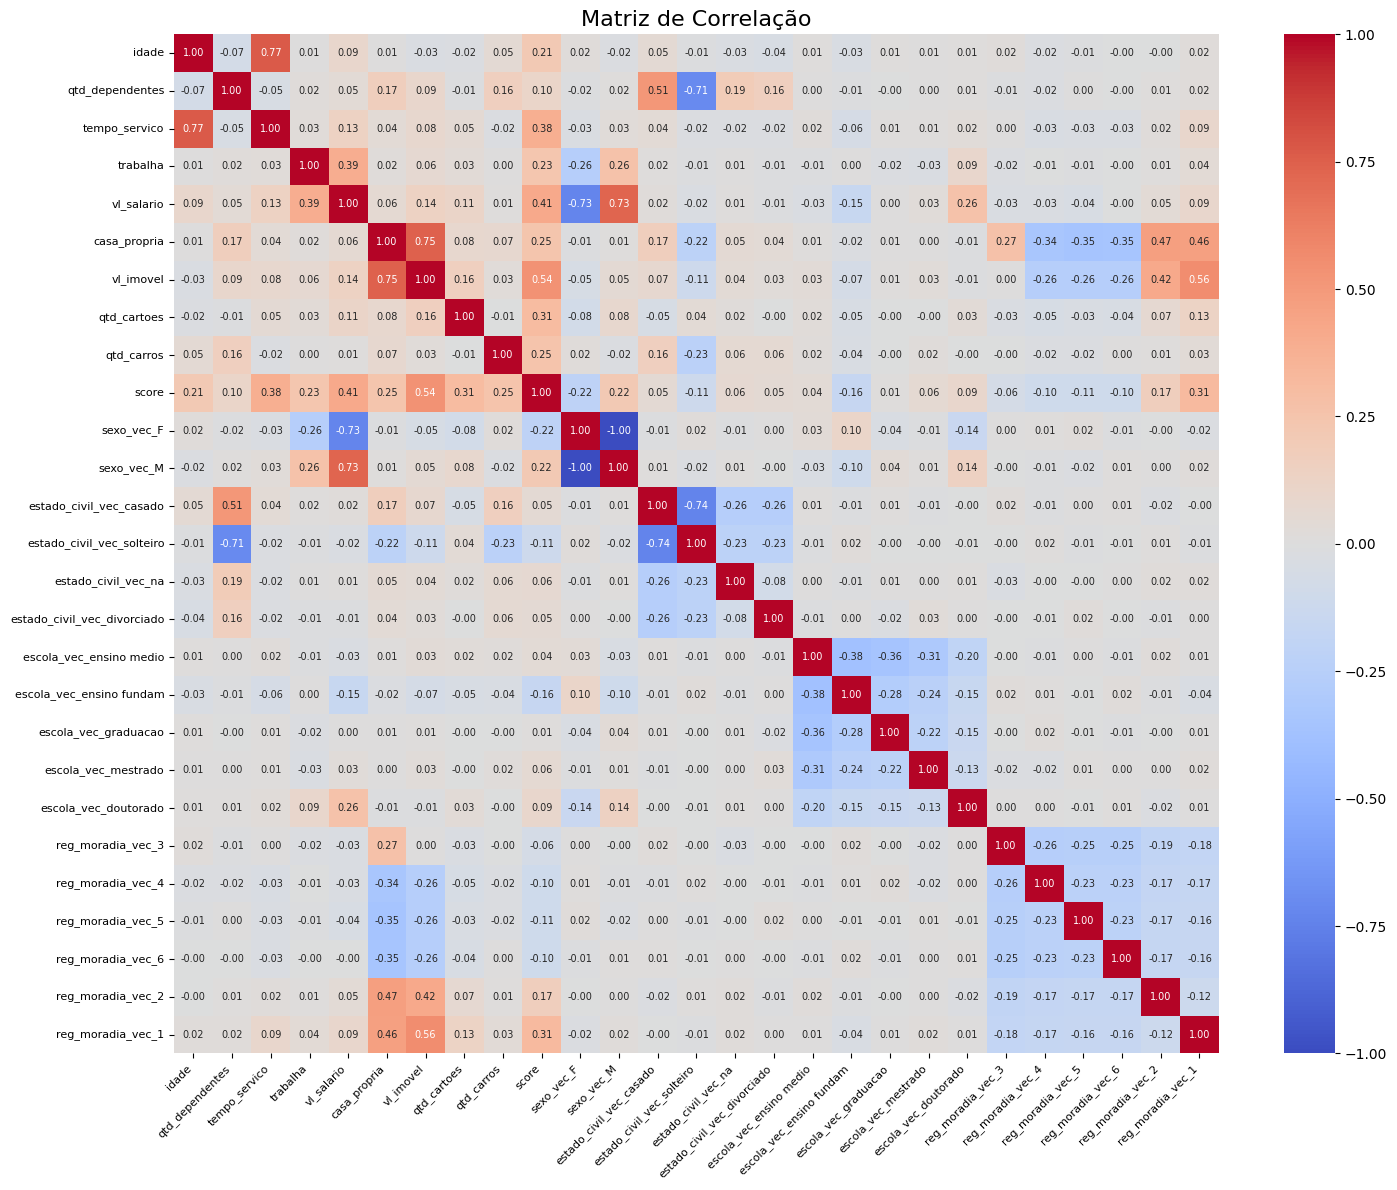

In [ ]:
plt.figure(figsize=(15, 12))  # aumenta a figura para comportar mais colunas

sns.heatmap(
    df_corr,
    annot=True,           # exibe os valores numéricos
    fmt=".2f",            # formata com 2 casas decimais
    annot_kws={"size": 7},# reduz o tamanho da fonte nas anotações
    cmap='coolwarm',      # mapa de cores
    vmin=-1,
    vmax=1
)

plt.title("Matriz de Correlação", fontsize=16)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

######Variáveis mais correlacionadas com o score

* **vl_imovel** se destaca como a variável mais correlacionada com o **score**, em torno de 0,53. Isso sugere que usuários com imóveis de maior valor tendem a ter um score de crédito mais alto.
* **vl_salario** apresenta correlação moderada, cerca de 0,41 com o **score**. Salários mais altos podem indicar maior capacidade de pagamento e, consequentemente, um score superior.
* **tempo_servico** (0,38), **qtd_cartoes** (0,31) e trabalha (~0,39) também mostram correlação positiva moderada com o **score**. Quanto mais tempo de serviço, maior número de cartões e estar empregado parecem elevar o score.
* **casa_propria** (0,25) e **qtd_carros** (0,26) exercem influência positiva, mas de forma menos intensa.

######Multicolinearidade Importante
* **casa_propria** e **vl_imovel** exibem correlação elevada (próxima de 0,75). Isso indica que usuários com casa própria também tendem a ter imóveis de valor mais alto, o que pode dificultar a interpretação dos coeficientes em um modelo linear.
**idade** e **tempo_servico** também têm correlação relativamente alta (por volta de 0,77), o que faz sentido: pessoas mais velhas geralmente têm mais tempo de serviço. No entanto, em modelos lineares, esse nível de correlação pode prejudicar a estabilidade das estimativas de coeficientes.

######Impacto Relativamente Menor de Outras Variáveis
* **qtd_dependentes** (~0,10) mostra correlação fraca com o **score**, indicando que, isoladamente, não é um grande preditor.
* **idade** tem correlação de cerca de 0,21 com o **score**, sugerindo alguma relação, mas não muito forte.
* As variáveis dummy (como **sexo_vec_F, sexo_vec_M, estado_civil_vec_, reg_moradia_vec_, etc**.) geralmente apresentam correlações mais baixas, o que indica menor influência isolada sobre o score ou um efeito mais distribuído entre as categorias.


##### Conclusão

**Principais Variáveis para Explicar o Score:**
*    vl_imovel, vl_salario, tempo_servico, qtd_cartoes e trabalha parecem ser as variáveis numéricas de maior relevância para explicar o score.

**Multicolinearidade:**

*    Devido à alta correlação entre casa_propria e vl_imovel, removemos do modelo a variável **casa_propria**
*    Devido à alta correlação entre idade e tempo_servico, removemos do modelo a variável **idade**

ProfAdelaide: As análises retiradas da matriz de correlação estão ok!
              Algumas considerações
              Variaveis qualitativas, mesmo que tenha sido transformada em numéricas(onehotencoder) devem ser avaliads com 
              o Chi-Quadrado
              Variáveis com a mesma informação é desnecessário para treinar modelos, por exemplo sexo_M (1,0) é a mesma coisa 
              que sexo_F(1,0) para alguns algoritmos pode gerar algum viés.

In [ ]:
df_raw.groupBy((when(col('vl_imovel').isNull(),0).otherwise(col('vl_imovel'))).alias('vl_imovel')).agg(count(lit(0)).alias('contagem')).orderBy('vl_imovel').show()

'''
~65% da base contem valor nullo para a variável vl_imovel, por isso acreditamos que podemos atribuír menor relevancia a esta variável quando comparada as demais
'''

+---------+--------+
|vl_imovel|contagem|
+---------+--------+
|      0.0|    6558|
|    150.0|       2|
|    151.0|       5|
|    152.0|       6|
|    153.0|       5|
|    154.0|      14|
|    155.0|       5|
|    156.0|       9|
|    157.0|       5|
|    158.0|       7|
|    159.0|      12|
|    160.0|       9|
|    161.0|       5|
|    162.0|       3|
|    163.0|       8|
|    164.0|       6|
|    165.0|      11|
|    166.0|       7|
|    167.0|       5|
|    168.0|       6|
+---------+--------+
only showing top 20 rows



In [ ]:
df_raw = df_raw.drop("casa_propria", "idade")
df_raw.printSchema()

root
 |-- qtd_dependentes: double (nullable = true)
 |-- tempo_servico: double (nullable = true)
 |-- trabalha: double (nullable = true)
 |-- vl_salario: double (nullable = true)
 |-- vl_imovel: double (nullable = true)
 |-- qtd_cartoes: double (nullable = true)
 |-- qtd_carros: double (nullable = true)
 |-- score: float (nullable = true)
 |-- sexo_vec_F: double (nullable = true)
 |-- sexo_vec_M: double (nullable = true)
 |-- estado_civil_vec_casado: double (nullable = true)
 |-- estado_civil_vec_solteiro: double (nullable = true)
 |-- estado_civil_vec_na: double (nullable = true)
 |-- estado_civil_vec_divorciado: double (nullable = true)
 |-- escola_vec_ensino medio: double (nullable = true)
 |-- escola_vec_ensino fundam: double (nullable = true)
 |-- escola_vec_graduacao: double (nullable = true)
 |-- escola_vec_mestrado: double (nullable = true)
 |-- escola_vec_doutorado: double (nullable = true)
 |-- reg_moradia_vec_3: double (nullable = true)
 |-- reg_moradia_vec_4: double (nullab

###Applied Model - Credit Scoring

####Por que Aplicar a Regressão Linear Múltipla?

1.   Natureza Contínua do Target:
O score é uma variável contínua que representa a pontuação de crédito, e a regressão linear múltipla é indicada justamente para prever valores numéricos.

2.   Interpretação dos Coeficientes:
O modelo permite quantificar o efeito de cada variável preditora sobre o score, facilitando a interpretação dos resultados (por exemplo, “a cada aumento de 1K no salário, o score aumenta em X pontos”).

3.   Simplicidade e Robustez:
É um modelo simples, rápido de ajustar e que serve como uma boa linha de base para comparações com modelos mais complexos, caso necessário.

4.   Verificação dos Pressupostos:
Permite avaliar os pressupostos de linearidade, homocedasticidade, normalidade dos resíduos e independência, o que contribui para uma análise mais aprofundada da qualidade dos dados e da adequação do modelo.

####Resolução dois

ProfAdelaide Sobre os comandos abaixo:
             Aqui vocês deixam nos comentários que deve ser excluída a variavel id, e isso pe muito importante que seja feito.
             Amostra treino e amostra teste ok!
             A Regressão linear utilizado no treino é de uma biblioteca que vocês não alteraram seus hiperparametros, neste caso,
             o default é  regParam: float = 0.0, elasticNetParam: float = 0.0, assim ele não faz ajustes de parametros.
             Entretanto não forneceu a significancia (p-value) de cada variável.

In [ ]:
# 1. Identificar as colunas que serão usadas como features (excluindo "score")
all_cols = df_raw.columns
target = "score"
features = [c for c in all_cols if c != target]

# Se necessário, posso remover colunas irrelevantes (por exemplo, 'id')
# excluded_cols = ["score", "id"]
# features = [c for c in all_cols if c not in excluded_cols]

print("Features utilizadas:", features)

# 2. Monta o vetor de features
assembler = VectorAssembler(inputCols=features, outputCol="features")
df_model = assembler.transform(df_raw).select("features", target)

# 3. Divisão dos dados em treino (80%) e teste (20%)
train_data, test_data = df_model.randomSplit([0.8, 0.2], seed=42)

# 4. Ajuste do modelo de Regressão Linear Múltipla
lr = LinearRegression(featuresCol="features", labelCol=target)
lr_model = lr.fit(train_data)

# Exibe os coeficientes e o intercepto do modelo
print("Coeficientes:", lr_model.coefficients)

# 5. Realiza previsões no conjunto de teste
predictions = lr_model.transform(test_data)
predictions.select("features", target, "prediction").show(5)

# 6. Avaliação do modelo utilizando métricas de regressão
evaluator_rmse = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="rmse")
evaluator_mse  = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="mse")
evaluator_r2   = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="r2")
evaluator_mae  = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="mae")

rmse = evaluator_rmse.evaluate(predictions)
mse  = evaluator_mse.evaluate(predictions)
r2   = evaluator_r2.evaluate(predictions)
mae  = evaluator_mae.evaluate(predictions)

print("Métricas do Modelo:")
print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)
print("R²:", r2)

# 7. Análise dos resíduos: adiciona coluna com os resíduos e exibe alguns exemplos
predictions = predictions.withColumn("residual", col(target) - col("prediction"))
predictions.select("residual").show(5)

Features utilizadas: ['qtd_dependentes', 'tempo_servico', 'trabalha', 'vl_salario', 'vl_imovel', 'qtd_cartoes', 'qtd_carros', 'sexo_vec_F', 'sexo_vec_M', 'estado_civil_vec_casado', 'estado_civil_vec_solteiro', 'estado_civil_vec_na', 'estado_civil_vec_divorciado', 'escola_vec_ensino medio', 'escola_vec_ensino fundam', 'escola_vec_graduacao', 'escola_vec_mestrado', 'escola_vec_doutorado', 'reg_moradia_vec_3', 'reg_moradia_vec_4', 'reg_moradia_vec_5', 'reg_moradia_vec_6', 'reg_moradia_vec_2', 'reg_moradia_vec_1']
Coeficientes: [4.487730595633923,5.026089296049635,45.52244782644089,0.6846769090919479,0.1960577549824727,77.71100472217087,58.02633135568488,7.852489291121766,-7.852489291115356,-11.659834198431776,6.842179637988463,7.264178477740747,11.523202475060483,4.909056060500267,-13.686770971229624,0.606103835886759,9.034400621505572,-0.48381057071415723,-12.601459164040332,21.16999364685564,21.515620767560705,17.5751754602942,-37.70956262274318,-31.36858512326294]
+--------------------

Número de features: 24
Número de coeficientes: 24


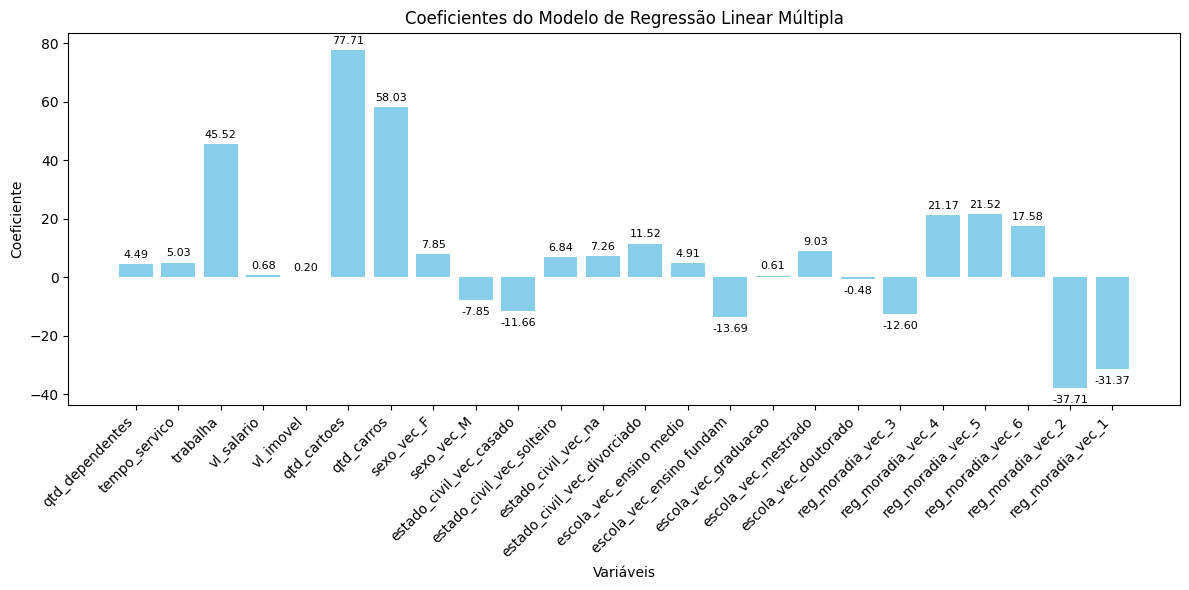

In [ ]:
# Função para extrair os nomes das features do metadata da coluna 'features'
def get_feature_names(df, vec_col="features"):
    metadata = df.schema[vec_col].metadata["ml_attr"]["attrs"]
    all_attrs = []
    for attr_type in metadata:
        all_attrs.extend(metadata[attr_type])
    all_attrs = sorted(all_attrs, key=lambda x: x["idx"])
    return [attr["name"] for attr in all_attrs]

# Extraio os nomes corretos dos atributos
feature_names = get_feature_names(df_model, "features")

# Extraio os coeficientes e converto para uma lista de floats
coef_array = lr_model.coefficients.toArray()

# Verifico se a quantidade de nomes e coeficientes é igual
print("Número de features:", len(feature_names))
print("Número de coeficientes:", len(coef_array))

# Ploto o gráfico de barras utilizando os nomes extraídos
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
bars = plt.bar(feature_names, coef_array, color='skyblue')
plt.xlabel("Variáveis")
plt.ylabel("Coeficiente")
plt.title("Coeficientes do Modelo de Regressão Linear Múltipla")
plt.xticks(rotation=45, ha="right")

# Adiciono rótulos com os valores dos coeficientes
for bar in bars:
    height = bar.get_height()
    if height >= 0:
        plt.annotate(f"{height:.2f}",
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=8)
    else:
        plt.annotate(f"{height:.2f}",
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, -5), textcoords="offset points",
                     ha='center', va='top', fontsize=8)

plt.tight_layout()
plt.show()


####Analisando o modelo:

RMSE (84.53): Indica que, em média, o erro quadrático raiz (em pontos) das previsões é de aproximadamente 84,53 pontos.

MSE (7145.16): Essa é a média dos erros ao quadrado. Valores altos são comuns, pois erros são elevados ao quadrado.

MAE (63.89): Representa o erro médio absoluto, ou seja, a diferença média em pontos entre o score real e o previsto.

R² (0.583): Significa que aproximadamente 58,3% da variabilidade do score é explicada pelas features utilizadas no modelo. Isso indica um desempenho moderado.

58% de variabilidade, quando relacionamos com o erro médio, de 84 pontos, para um score que varia de 0 a 1000, temos um desempenho que já poderia ser considerado moderado.

Importante ressaltar que o valor do coeficiente não necessariamente é o valor da correlação com a variável target. Visto que a variável de maior influência (vl_imovel) tem um coeficiente baixo, já que seus valores são de maior grandeza do que a variável (qtd_cartoes), por exemplo.

Quando voltamos a análise do nosso dataset, podemos trabalhar com algumas variáveis para ver a influência no novo modelo.

Observamos que a variável de maior peso no modelo possuem muitos valores iguais a zero (aproximadamente 60%), o que poderia estar influenciando negativamente a performance do modelo, especialmente a variável Valor de Imóvel.
Isso ocorre porque valores concentrados em um único ponto (como zero) podem reduzir a variabilidade da informação e dificultar a diferenciação entre as classes ou padrões previstos.

Para mitigar esse impacto, optamos por atribuir um peso às observações com valor zero nessa variável, garantindo que o modelo levasse em consideração sua importância e influência de maneira mais equilibrada.

####Resolução dois:

In [ ]:
df_raw = (
    df_raw
    .withColumn("weight",when(col('vl_imovel')==0,1).otherwise(2))
    .drop('sexo','estado_civil','escola')
)

df_raw.show()

+-----+---------------+-------------+--------+------------------+-----------+------------+---------+-----------+----------+------------------+----------+----------+-----------------------+-------------------------+-------------------+---------------------------+-----------------------+------------------------+--------------------+-------------------+--------------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+------+
|idade|qtd_dependentes|tempo_servico|trabalha|        vl_salario|reg_moradia|casa_propria|vl_imovel|qtd_cartoes|qtd_carros|             score|sexo_vec_F|sexo_vec_M|estado_civil_vec_casado|estado_civil_vec_solteiro|estado_civil_vec_na|estado_civil_vec_divorciado|escola_vec_ensino medio|escola_vec_ensino fundam|escola_vec_graduacao|escola_vec_mestrado|escola_vec_doutorado|reg_moradia_vec_3|reg_moradia_vec_4|reg_moradia_vec_5|reg_moradia_vec_6|reg_moradia_vec_2|reg_moradia_vec_1|weight|
+-----+---------------

In [ ]:
# 1. Identificar as colunas que serão usadas como features (excluindo "score" e "weight")
all_cols = df_raw.columns
print(all_cols)

target = "score"

features = [c for c in all_cols if c not in [target, "weight"]]

print("Features utilizadas:", features)

# 2. Monta o vetor de features
assembler = VectorAssembler(inputCols=features, outputCol="features")
print(assembler)

# Aqui selecionamos também a coluna weight, além de target, para uso posterior
df_model = assembler.transform(df_raw).select("features", target, "weight")

# 3. Divisão dos dados em treino (80%) e teste (20%)
train_data, test_data = df_model.randomSplit([0.8, 0.2], seed=42)

# 4. Ajuste do modelo de Regressão Linear Múltipla COM peso
lr = LinearRegression(
    featuresCol="features",
    labelCol=target,
    weightCol="weight"   # Adicionando o peso da coluna vl_imovel em relação ao modelo
)
lr_model = lr.fit(train_data) ## Treinando o modelo

# Exibe os coeficientes e o intercepto do modelo
print("Coeficientes:", lr_model.coefficients) ##Pegando do modelo o coefficiente por

# 5. Realiza previsões no conjunto de teste
predictions = lr_model.transform(test_data)
predictions.select("features", target, "prediction").show(5)

# 6. Avaliação do modelo utilizando métricas de regressão
evaluator_rmse = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="rmse")
evaluator_mse  = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="mse")
evaluator_r2   = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="r2")
evaluator_mae  = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="mae")

rmse = evaluator_rmse.evaluate(predictions)
mse  = evaluator_mse.evaluate(predictions)
r2   = evaluator_r2.evaluate(predictions)
mae  = evaluator_mae.evaluate(predictions)

print("Métricas do Modelo:")
print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)
print("R²:", r2)

# 7. Análise dos resíduos
predictions = predictions.withColumn("residual", col(target) - col("prediction"))
predictions.select("residual").show(5)

['idade', 'qtd_dependentes', 'tempo_servico', 'trabalha', 'vl_salario', 'reg_moradia', 'casa_propria', 'vl_imovel', 'qtd_cartoes', 'qtd_carros', 'score', 'sexo_vec_F', 'sexo_vec_M', 'estado_civil_vec_casado', 'estado_civil_vec_solteiro', 'estado_civil_vec_na', 'estado_civil_vec_divorciado', 'escola_vec_ensino medio', 'escola_vec_ensino fundam', 'escola_vec_graduacao', 'escola_vec_mestrado', 'escola_vec_doutorado', 'reg_moradia_vec_3', 'reg_moradia_vec_4', 'reg_moradia_vec_5', 'reg_moradia_vec_6', 'reg_moradia_vec_2', 'reg_moradia_vec_1', 'weight']
Features utilizadas: ['idade', 'qtd_dependentes', 'tempo_servico', 'trabalha', 'vl_salario', 'reg_moradia', 'casa_propria', 'vl_imovel', 'qtd_cartoes', 'qtd_carros', 'sexo_vec_F', 'sexo_vec_M', 'estado_civil_vec_casado', 'estado_civil_vec_solteiro', 'estado_civil_vec_na', 'estado_civil_vec_divorciado', 'escola_vec_ensino medio', 'escola_vec_ensino fundam', 'escola_vec_graduacao', 'escola_vec_mestrado', 'escola_vec_doutorado', 'reg_moradia_vec

ProfAdelaide: Nos coeficientes demonstrados acima faltou colocar o pvalue (significancia ) 
              Fazer a analise de resíduos
              Na disciplina também vimos a Árvore de Regressão que pode ser uma alternativa, inclusive de comparação;
              Faltou a simulação, implementação do algoritmo com pesos e seu cálculo

# Aprimoramento do Modelo e Impacto na Performance
Inicialmente, o modelo apresentava uma acurácia de 58%, o que indicava uma margem de melhoria. Para identificar possíveis pontos a serem trabalhados, foi realizada uma análise da distribuição dos dados e da presença de outliers.

Após acrescentar um peso para valores iguais a zero na variável de maior peso, tivemos uma melhora e o modelo conseguiu uma acurácia de 63.8%, com um erro médio de 80.68.

Esse resultado reforça a importância de uma análise detalhada dos dados e da distribuição das variáveis para a otimização do modelo preditivo.

Consideramos que as variáveis dadas foram suficientes para tomada de decisão, visto que temos uma boa acurácia e um erro médio pequeno face a range total da variável target.

## Recomendações
A análise mais aprofundada de forma individual de cada variável se mostrou muito positiva na melhoria da eficicácia do modelo.

Dois exemplos são o caso de qtd_cartoes, que também possui valores a zero e poderia influenciar o modelo positivamente caso esses recebam um peso.
Outra como tempo_servico também precisa de uma validação mais profunda, o resultado até então é de pouca influência, mas ao dividir por clusters poderíamos entender melhor se uma pessoa com muito ou pouco tempo de serviço vai ter um bom score.


Outras variáveis poderiam enriquecer o modelo, como tempo de atraso de pagamento, qual o critério da empresa para considerar clientes inadimplentes e também um dataset de clientes considerados bons pagadores e de clientes considerados inadimplentes.

Para a análise, ententer a relação entre o valor do score e a inadimplência do cliente, enriqueceria o trabalho apresentado.

In [ ]:
ProfAdelaide Aqui poderia ser usado a técnica de componentes princiapis(PCA) par redução da dimensionalidade 
             para as várias muito correlacionadas ( a essa altura vocês ja devem terem visto em Feature engineering)
             Uma observação quando se colocar variáveis de comportamento de pagamento não se trata de creditScoring mas 
             sim Behavior Scoring é outro modelo.